# 📧 Email Spam Classification using NLP

## 1. Business Problem

Email spam is one of the most common cybersecurity challenges faced by individuals and organizations. Spam emails waste user's time, consume storage resources, and often contain phishing attempts or malicious links.

The objective of this project is to build a machine learning model that automatically classifies emails as **Spam** or **Not Spam** using Natural Language Processing (NLP) techniques.

This project demonstrates an end-to-end machine learning workflow including data preprocessing, feature engineering, model training, evaluation, and deployment using FastAPI and Streamlit.

## Dataset Information

The dataset contains labeled email messages belonging to two classes:

- Spam
- Ham (Not Spam)

Each record contains:

- Email Text
- Label
- Message length
- number of punctuations used in a message

Goal:

Predict whether a new email belongs to the Spam or Not Spam category.

## 2. Import liabraries

In [118]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Natural Language Processing
import nltk
import string

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from collections import Counter

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# joblib

import joblib

## 3. Load Dataset

In [119]:
df=pd.read_csv(r"C:\Users\Admin\Desktop\Shrawani\Projects\Email_Spam_Classifier\data\spam.tsv",sep='\t')

In [120]:
df.head()

,label,message,length,punct
0,ham,"Go until jurong point, crazy.. Available only ...",111,9
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,6
3,ham,U dun say so early hor... U c already then say...,49,6
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,2


## Dataset Overview

In [121]:
df.shape

(5572, 4)

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
 2   length   5572 non-null   int64 
 3   punct    5572 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 174.3+ KB


In [123]:
df.describe()

,length,punct
count,5572.000000,5572.000000
mean,80.489950,4.177495
std,59.942907,4.623919
min,2.000000,0.000000
25%,36.000000,2.000000
50%,62.000000,3.000000
75%,122.000000,6.000000
max,910.000000,133.000000


### Data Quality Checks

In [124]:
print("Number of missing values in each column:")
df.isnull().sum()

Number of missing values in each column:


label      0
message    0
length     0
punct      0
dtype: int64

#### Observation:

- The dataset contains no missing values.
- Since all columns are complete, no imputation or removal of missing records was required.
- The dataset is suitable for further preprocessing and model development.

In [125]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 403


In [126]:
df = df.drop_duplicates()

In [127]:
print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (5169, 4)


In [128]:
df.duplicated().sum()

np.int64(0)

#### Observation

- The dataset initially contained 403 duplicate records.
- Duplicate entries were removed to improve data quality and prevent the model from learning repeated samples.
- After removing duplicates, the dataset contained 5,169 unique email records.

## 4. Exploratory Data Analysis

### Class Distribution

In [129]:
class_distribution=df["label"].value_counts()
print(class_distribution)

print("\nPercentage Distribution:")
print((class_distribution / len(df) * 100).round(2))

label
ham     4516
spam     653
Name: count, dtype: int64

Percentage Distribution:
label
ham     87.37
spam    12.63
Name: count, dtype: float64


#### Observation

- The majority of email messages belong to the **ham** class, while the **spam** class represents a much smaller portion of the dataset.
- This indicates a **class imbalance**, which is common in real-world spam detection datasets.
- During model evaluation, special attention will be given to **precision**, **recall**, and **F1-score** to ensure the model performs well on the minority (spam) class.

### Message Length Analysis

In [130]:
df.groupby("label")["length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,70.905890,56.715046,2.0,34.0,53.0,91.0,910.0
spam,653.0,137.704441,29.821348,13.0,132.0,148.0,157.0,223.0


#### Observation

- Ham messages have an average length of approximately **71 characters**, whereas spam messages average around **138 characters**.
- This indicates that spam messages are generally longer than legitimate messages, likely due to promotional content, advertisements, or phishing attempts.
- Ham messages exhibit greater variability in length, while spam messages are more consistent in size.
- Message length appears to be a potentially useful feature for distinguishing spam from ham emails.

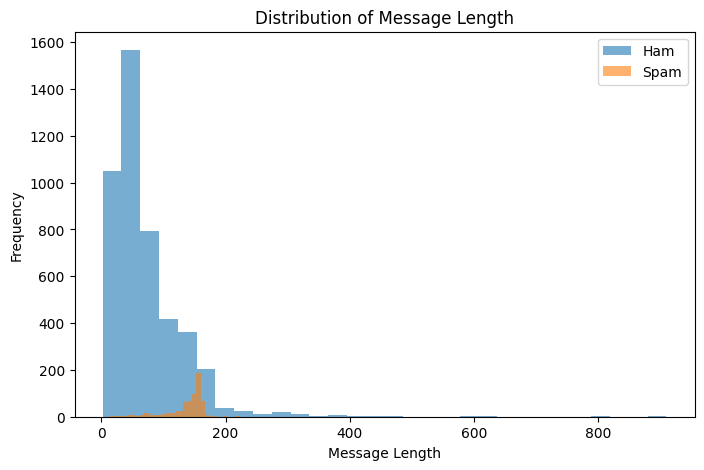

In [131]:
plt.figure(figsize=(8,5))
plt.hist(df[df["label"]=="ham"]["length"], bins=30, alpha=0.6, label="Ham")
plt.hist(df[df["label"]=="spam"]["length"], bins=30, alpha=0.6, label="Spam")
plt.legend()
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.title("Distribution of Message Length")
plt.show()

#### Observation

- The histogram shows that ham messages are generally shorter, whereas spam messages tend to contain more characters.
- Spam messages are concentrated around higher message lengths, indicating that promotional or phishing content is typically longer than legitimate messages.
- Although there is some overlap between the two classes, message length provides useful discriminatory information and can be considered an informative feature during exploratory data analysis.
- Since both classes overlap in certain length ranges, message length alone is insufficient for classification. Therefore, Natural Language Processing techniques such as TF-IDF will be used to capture the textual content of the messages for accurate prediction.

### Punctuation Analysis

In [132]:
df.groupby("label")["punct"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,3.830159,4.488122,0.0,1.0,3.0,5.0,133.0
spam,653.0,5.643185,3.500627,0.0,3.0,5.0,8.0,26.0


#### Observation

- Spam messages contain a higher average number of punctuation marks (5.64) compared to ham messages (3.83).
- This suggests that spam messages often use excessive punctuation to attract the reader's attention or create a sense of urgency.
- Ham messages show greater variability in punctuation usage, indicating more diverse writing styles.
- Although punctuation count provides useful information, it is not sufficient on its own to distinguish spam from ham messages. It should be considered as a supporting feature alongside textual features extracted using NLP techniques.

## Data Preparation

In this phase, the text data is cleaned and transformed into a format suitable for machine learning. The preprocessing pipeline removes unnecessary information while preserving meaningful textual features that can improve classification performance.

In [133]:
# Download nltk resources


nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Error loading punkt_tab: <urlopen error [WinError 10054]
[nltk_data]     An existing connection was forcibly closed by the
[nltk_data]     remote host>
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Create Stemmer

In [134]:
ps = PorterStemmer()

### Create the Preprocessing Function

In [135]:
def transform_text(text):

    # Convert to lowercase
    text = text.lower()

    # Tokenize the text
    text = nltk.word_tokenize(text)

    words = []

    # Keep only alphanumeric tokens
    for word in text:
        if word.isalnum():
            words.append(word)

    filtered_words = []

    # Remove stopwords
    for word in words:
        if word not in stopwords.words("english"):
            filtered_words.append(word)

    stemmed_words = []

    # Apply stemming
    for word in filtered_words:
        stemmed_words.append(ps.stem(word))

    return " ".join(stemmed_words)

### Function Test

In [136]:
sample = "Congratulations!! You have won a FREE iPhone. Click here now!!"

print(transform_text(sample))

congratul free iphon click


## 5. NLP Preprocessing Pipeline

The preprocessing function performs the following operations:

1. Converts all text to lowercase.
2. Splits the sentence into individual words (tokenization).
3. Removes non-alphanumeric characters.
4. Removes common English stopwords such as *the*, *is*, and *and*.
5. Applies Porter Stemming to reduce words to their root form.
6. Returns the cleaned text for feature extraction.

## Feature Engineering

In this phase, the cleaned text generated during preprocessing is transformed into meaningful features for machine learning. 
Before vectorization, the cleaned text is analyzed to identify the most frequent words in spam and ham messages.
This provides insights into the vocabulary used by each class.

### Apply the preprocessing function

In [137]:
df["transformed_text"] = df["message"].apply(transform_text)

In [138]:
df[["message", "transformed_text"]].head()

,message,transformed_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


#### Observation

A new column named **transformed_text** was created to store the cleaned version of each email message. Keeping the original and 
transformed text separately preserves the raw data while allowing the machine learning model to use the processed text for feature extraction.

### Word Count Analysis

In [139]:
# most frequent words in spam

In [140]:
df

,label,message,length,punct,transformed_text
0,ham,"Go until jurong point, crazy.. Available only ...",111,9,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,29,6,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,6,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,49,6,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,2,nah think goe usf live around though
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,160,8,2nd time tri 2 contact u pound prize 2 claim e...
5568,ham,Will ü b going to esplanade fr home?,36,1,ü b go esplanad fr home
5569,ham,"Pity, * was in mood for that. So...any other s...",57,7,piti mood suggest
5570,ham,The guy did some bitching but I acted like i'd...,125,1,guy bitch act like interest buy someth els nex...


In [141]:
spam_words = []

for message in df[df["label"] == 'spam']["transformed_text"]:
    spam_words.extend(message.split())

Counter(spam_words).most_common(30)

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 120),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 108),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 61),
 ('urgent', 58),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

#### Observation


The frequency analysis of spam messages reveals that words such as **call**, **free**, **txt**, **text**, **reply**, **claim**, **prize**, **mobile**, and **urgent** occur most frequently. These words are commonly associated with promotional offers, lottery scams, and phishing messages, indicating clear linguistic patterns that distinguish spam from legitimate messages.

Numeric tokens such as **2** and **4** also appear frequently because many spam messages contain instructions like *"Reply 2"*, *"Call 2 claim"*, or *"Text 2 win"*. These tokens were intentionally retained during preprocessing as they may carry useful information for spam classification.

The presence of these high-frequency terms suggests that the dataset contains distinctive vocabulary, which can be effectively captured by feature extraction techniques such as **TF-IDF** for building an accurate spam detection model.

### Most frequent words in ham

In [142]:
ham_words = []

for message in df[df["label"] == 'ham']["transformed_text"]:
    ham_words.extend(message.split())

Counter(ham_words).most_common(30)

[('u', 897),
 ('go', 407),
 ('get', 351),
 ('2', 288),
 ('gt', 288),
 ('lt', 287),
 ('come', 278),
 ('got', 239),
 ('know', 237),
 ('like', 236),
 ('call', 235),
 ('love', 222),
 ('time', 220),
 ('ok', 218),
 ('good', 215),
 ('want', 209),
 ('ur', 203),
 ('day', 195),
 ('ü', 173),
 ('need', 171),
 ('one', 166),
 ('4', 162),
 ('lor', 159),
 ('home', 152),
 ('think', 150),
 ('see', 148),
 ('take', 144),
 ('still', 144),
 ('da', 142),
 ('tell', 133)]

#### Observation

The most common words in ham messages are everyday conversational words related to personal communication. This reflects the
natural language used in legitimate text messages.

### WordCloud

In [143]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


### Spam WordCloud

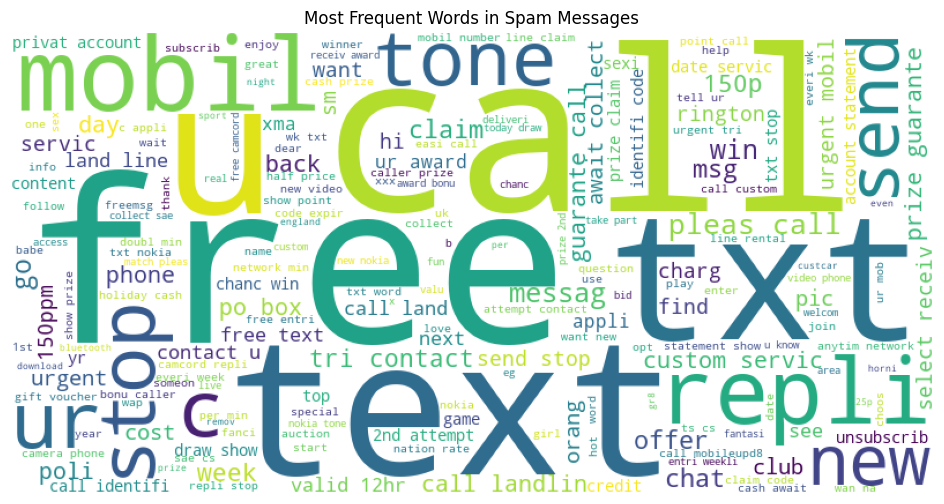

In [144]:
spam_wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(" ".join(spam_words))

plt.figure(figsize=(12,6))
plt.imshow(spam_wc)
plt.axis("off")
plt.title("Most Frequent Words in Spam Messages")
plt.show()

#### Observation

The WordCloud highlights the most frequently occurring words in spam messages after text preprocessing. Words such as **free**, 
**text**, **call**, **reply**, **claim**, **win**, and **offer** appear prominently, indicating that spam messages are largely 
promotional and action-oriented. The visualization also confirms that the preprocessing pipeline has successfully removed common stopwords 
and reduced words to their root forms using stemming. These distinctive terms are expected to contribute significantly to the machine learning model 
during feature extraction using TF-IDF.

### Ham WordCloud

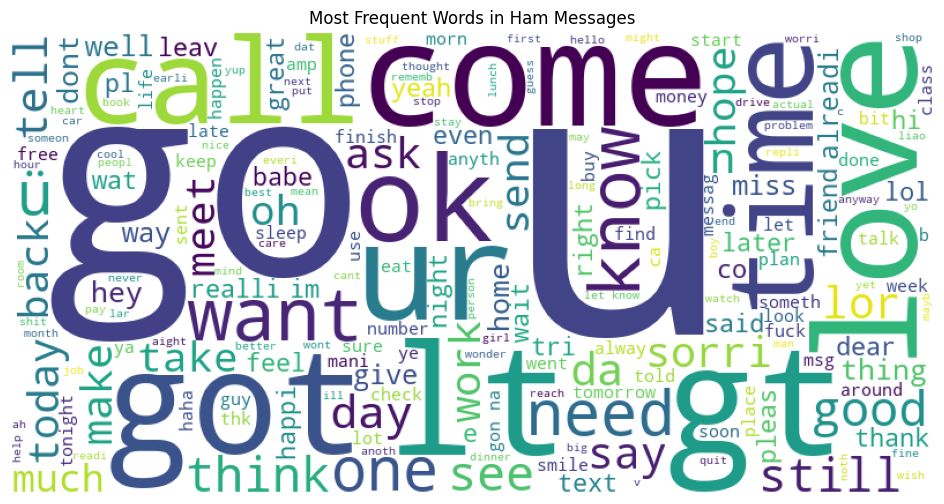

In [182]:
ham_wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(" ".join(ham_words))

plt.figure(figsize=(12,6))
plt.imshow(ham_wc)
plt.axis("off")
plt.title("Most Frequent Words in Ham Messages")
plt.show()

#### Observation

The WordCloud for ham messages highlights commonly used conversational words such as **go**, **come**, **love**, **know**, **good**, and **time**. These words reflect everyday personal communication and differ significantly from the promotional vocabulary observed in spam messages. The visualization confirms that the preprocessing pipeline has effectively cleaned the text while preserving meaningful words that will be used for feature extraction.

# 6. Label Encoding

Machine learning algorithms require the target variable to be represented in numerical form. Therefore, the categorical labels (**ham** and **spam**) are converted into numerical values using **LabelEncoder**.

Encoding Scheme:

- **ham → 0**
- **spam → 1**

This transformation affects only the target variable and does not modify the message content.

In [183]:
encoder = LabelEncoder()

In [184]:
df["label"] = encoder.fit_transform(df["label"])

In [185]:
print("Classes:", encoder.classes_)

print("\nEncoded Labels:")
print(df["label"].value_counts())

print("\nSample Data:")
df.head()

Classes: [0 1]

Encoded Labels:
label
0    4516
1     653
Name: count, dtype: int64

Sample Data:


,label,message,length,punct,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,9,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,6,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,6,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,6,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,2,nah think goe usf live around though


#### Observation

The target variable was successfully encoded into numerical values using LabelEncoder. The encoded labels preserve the original class distribution while making the dataset compatible with machine learning algorithms.

- **0** represents **ham**
- **1** represents **spam**

# 7. Feature Extraction using TF-IDF

Machine learning algorithms cannot process raw text directly. Therefore, the cleaned text is converted into numerical feature vectors using **Term Frequency–Inverse Document Frequency (TF-IDF)**.

TF-IDF assigns higher weights to words that are important in a document but less common across the entire dataset. This helps the model focus on informative words while reducing the influence of frequently occurring but less meaningful terms.

In [186]:
tfidf = TfidfVectorizer(max_features=3000)

In [187]:
df.head()

,label,message,length,punct,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,9,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,6,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,6,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,6,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,2,nah think goe usf live around though


In [188]:
X = tfidf.fit_transform(df["transformed_text"]).toarray()
y = df["label"]

In [189]:
y

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: label, Length: 5169, dtype: int64

In [190]:
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (5169, 3000)
Target Shape: (5169,)


In [191]:
df["label"].head()

0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64

In [192]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:100])

['0207' '0776xxxxxxx' '07xxxxxxxxx' '0800' '08000407165' '08000776320'
 '08000839402' '08000930705' '08001950382' '08002986906' '0845' '0870'
 '08701417012' '08707509020' '08712300220' '08712405020' '08712460324'
 '08715705022' '08718720201' '08718727870' '08718730666' '09050003091'
 '09050090044' '09056242159' '09058094565' '09061209465' '09061213237'
 '09061221066' '09061743386' '09061743806' '09061790121' '09063458130'
 '09066350750' '09066358152' '09066362231' '09066380611' '09066612661'
 '09071512433' '10' '100' '1000' '1030' '10k' '10p' '10ppm' '11' '11mth'
 '12' '121' '125gift' '12hr' '12mth' '1327' '150' '150p' '150pm' '150ppm'
 '153' '16' '18' '18yr' '1hr' '1st' '20' '200' '2000' '2003' '2004' '2007'
 '20p' '21' '21870000' '21st' '24' '24hr' '25' '250' '25p' '26th' '28'
 '2day' '2find' '2geva' '2go' '2marrow' '2moro' '2morow' '2morro'
 '2morrow' '2mrw' '2nd' '2nite' '2optout' '2p' '2rcv' '2stoptxt' '2u'
 '2waxsto' '2wk' '2wt']


#### Observation

The TF-IDF vocabulary includes both numeric tokens (such as phone numbers and service codes) and meaningful English words. Since the vocabulary 
is sorted alphabetically, numeric tokens appear first. These tokens are retained because they may contain useful information for identifying spam
messages, where phone numbers and service codes occur frequently.

# 8. Train-Test Split

Before training the machine learning model, the dataset is divided into training and testing subsets.

- **Training Set:** Used to train the machine learning model.
- **Testing Set:** Used to evaluate the model on unseen data.

An 80:20 split is used, where 80% of the data is used for training and 20% for testing.

A fixed `random_state` is specified to ensure reproducibility, and `stratify=y` is used to preserve the original class distribution in both subsets.

### Split dataset

In [193]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Verify the Shapes

In [194]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (4135, 3000)
Testing Features  : (1034, 3000)
Training Labels   : (4135,)
Testing Labels    : (1034,)


### Verify Class Distribution

In [195]:
print("Original Dataset")
print(y.value_counts(normalize=True))

print("\nTraining Dataset")
print(y_train.value_counts(normalize=True))

print("\nTesting Dataset")
print(y_test.value_counts(normalize=True))

Original Dataset
label
0    0.87367
1    0.12633
Name: proportion, dtype: float64

Training Dataset
label
0    0.873761
1    0.126239
Name: proportion, dtype: float64

Testing Dataset
label
0    0.873308
1    0.126692
Name: proportion, dtype: float64


In [196]:
# This confirms that stratify=y worked correctly.

#### Observation

The dataset was divided into training and testing subsets using an 80:20 ratio. Stratified sampling was applied to preserve the original 
class distribution in both subsets, ensuring fair model evaluation and reducing sampling bias.

# 9. Model Training

Multiple machine learning algorithms are trained and evaluated to identify the most suitable model for email spam classification. Each model is trained using the same training dataset and evaluated on the same testing dataset to ensure a fair comparison.

The following evaluation metrics are considered:

- Accuracy
- Precision
- Recall
- F1-Score

These metrics provide a comprehensive understanding of each model's performance, especially since the dataset is imbalanced.

## 9.1 Multinomial Naive Bayes

Multinomial Naive Bayes is one of the most widely used algorithms for text classification tasks. It performs exceptionally well on high-dimensional sparse data such as TF-IDF vectors and serves as a strong baseline for spam detection problems.

In [197]:
mnb = MultinomialNB()

In [198]:
mnb.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [199]:
y_pred = mnb.predict(X_test)

### Model evaluation

In [200]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9768
Precision: 1.0000
Recall   : 0.8168
F1 Score : 0.8992


In [201]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       903
           1       1.00      0.82      0.90       131

    accuracy                           0.98      1034
   macro avg       0.99      0.91      0.94      1034
weighted avg       0.98      0.98      0.98      1034



In [202]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[903   0]
 [ 24 107]]


#### Observation

The Multinomial Naive Bayes classifier achieved an **accuracy of 97.68%**, demonstrating excellent overall performance on the email spam classification task.

The model achieved **100% precision**, indicating that every message predicted as spam was indeed spam. This means the model produced **no false positives**, ensuring that legitimate emails were not incorrectly classified as spam.

However, the recall of **81.68%** shows that a small number of spam messages were missed (false negatives). Although this is a strong baseline model for text classification, additional algorithms will be evaluated to determine whether higher recall and overall performance can be achieved.

## 9.2 Model Evaluation Function

To ensure a fair comparison, a reusable evaluation function is created. This function trains a machine learning model, generates predictions, and calculates the evaluation metrics consistently for every algorithm.

The following metrics are evaluated:

- Accuracy
- Precision
- Recall
- F1-Score

In [203]:
def evaluate_model(model, X_train, y_train, X_test, y_test):

    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("="*60)
    print(model.__class__.__name__)
    print("="*60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix\n")
    print(confusion_matrix(y_test, y_pred))

    return {
    "Model": model.__class__.__name__,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "Confusion Matrix": confusion_matrix(y_test, y_pred),
    "Classification Report": classification_report(y_test, y_pred, output_dict=True)
}

## 9.3 Logistic Regression

Logistic Regression is a linear classification algorithm that performs exceptionally well on high-dimensional sparse feature spaces such as TF-IDF 
vectors. It is widely used as a strong baseline for text classification problems.

In [204]:
lr = LogisticRegression(random_state=42)

lr_results = evaluate_model(
    lr,
    X_train,
    y_train,
    X_test,
    y_test
)

LogisticRegression
Accuracy : 0.9545
Precision: 0.9667
Recall   : 0.6641
F1 Score : 0.7873

Classification Report

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       903
           1       0.97      0.66      0.79       131

    accuracy                           0.95      1034
   macro avg       0.96      0.83      0.88      1034
weighted avg       0.96      0.95      0.95      1034


Confusion Matrix

[[900   3]
 [ 44  87]]


#### Observation

The Logistic Regression model achieved an **accuracy of 95.45%** with a **precision of 96.67%**. Although the model correctly classified the majority of ham messages, its **recall of 66.41%** indicates that a significant number of spam messages were not detected.

Compared with the Multinomial Naive Bayes classifier, Logistic Regression produced more false negatives and slightly more false positives, resulting in lower overall performance on this dataset. Therefore, Multinomial Naive Bayes remains the stronger baseline model at this stage.

## 9.4 Random Forest Classifier

Random Forest is an ensemble learning algorithm that constructs multiple decision trees and combines their predictions to improve classification performance. It is robust to overfitting and is widely used for classification tasks. In this project, it is evaluated to compare its performance with models specifically suited for text classification.

In [205]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_results = evaluate_model(
    rf,
    X_train,
    y_train,
    X_test,
    y_test
)

RandomForestClassifier
Accuracy : 0.9729
Precision: 0.9640
Recall   : 0.8168
F1 Score : 0.8843

Classification Report

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       903
           1       0.96      0.82      0.88       131

    accuracy                           0.97      1034
   macro avg       0.97      0.91      0.93      1034
weighted avg       0.97      0.97      0.97      1034


Confusion Matrix

[[899   4]
 [ 24 107]]


#### Observation

The Random Forest classifier achieved an **accuracy of 97.29%**, making it one of the strongest models evaluated in this project. Its **recall of 81.68%** matched that of the Multinomial Naive Bayes classifier, successfully identifying the same number of spam messages.

However, Random Forest produced **four false positives**, resulting in slightly lower precision and F1-score compared to Multinomial Naive Bayes. Although Random Forest demonstrated excellent overall performance, Multinomial Naive Bayes remained the best-performing model at this stage.

## 9.5 Decision Tree Classifier

Decision Tree is a rule-based supervised learning algorithm that splits the dataset into decision nodes based on feature values. Although decision trees are easy to interpret, they can be prone to overfitting, especially when dealing with high-dimensional sparse text data. In this project, the Decision Tree classifier is evaluated to compare its performance with other machine learning algorithms.

In [206]:
dt = DecisionTreeClassifier(random_state=42)

dt_results = evaluate_model(
    dt,
    X_train,
    y_train,
    X_test,
    y_test
)

DecisionTreeClassifier
Accuracy : 0.9429
Precision: 0.7727
Recall   : 0.7786
F1 Score : 0.7757

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       903
           1       0.77      0.78      0.78       131

    accuracy                           0.94      1034
   macro avg       0.87      0.87      0.87      1034
weighted avg       0.94      0.94      0.94      1034


Confusion Matrix

[[873  30]
 [ 29 102]]


#### Observation

The Decision Tree classifier achieved an **accuracy of 94.29%** with an **F1-score of 77.57%**. While the model was able to classify a majority of the emails correctly, it generated a relatively high number of both false positives and false negatives compared to the previously evaluated models.

The lower precision indicates that several legitimate emails were incorrectly classified as spam, making the Decision Tree less suitable for this text classification task. Overall, its performance was inferior to both Multinomial Naive Bayes and Random Forest.

## 9.6 K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is an instance-based learning algorithm that classifies a data point based on the majority class of its nearest neighbors. Although KNN is simple and intuitive, it can be computationally expensive and may struggle with high-dimensional sparse data such as TF-IDF feature vectors. The model is evaluated to compare its effectiveness with other machine learning algorithms.

In [207]:
knn = KNeighborsClassifier(n_neighbors=5)

knn_results = evaluate_model(
    knn,
    X_train,
    y_train,
    X_test,
    y_test
)

KNeighborsClassifier
Accuracy : 0.9052
Precision: 0.9714
Recall   : 0.2595
F1 Score : 0.4096

Classification Report

              precision    recall  f1-score   support

           0       0.90      1.00      0.95       903
           1       0.97      0.26      0.41       131

    accuracy                           0.91      1034
   macro avg       0.94      0.63      0.68      1034
weighted avg       0.91      0.91      0.88      1034


Confusion Matrix

[[902   1]
 [ 97  34]]


#### Observation

The K-Nearest Neighbors (KNN) classifier achieved an **accuracy of 90.52%**, but its **recall of only 25.95%** indicates that the model failed to identify a large proportion of spam emails.

Although the model maintained a high precision of **97.14%**, it produced **97 false negatives**, making it unsuitable for spam detection where identifying spam messages is essential. The poor performance can be attributed to the high-dimensional sparse nature of TF-IDF features, where distance-based algorithms such as KNN are less effective.

## 9.7 Linear Support Vector Machine (Linear SVM)

Linear Support Vector Machine (Linear SVM) is a supervised learning algorithm that is particularly effective for high-dimensional sparse datasets such as TF-IDF feature vectors. It identifies the optimal decision boundary that maximizes the separation between classes and is widely used in natural language processing tasks due to its strong generalization performance.

In [208]:
svm = LinearSVC(random_state=42)

svm_results = evaluate_model(
    svm,
    X_train,
    y_train,
    X_test,
    y_test
)

LinearSVC
Accuracy : 0.9787
Precision: 0.9658
Recall   : 0.8626
F1 Score : 0.9113

Classification Report

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.97      0.86      0.91       131

    accuracy                           0.98      1034
   macro avg       0.97      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034


Confusion Matrix

[[899   4]
 [ 18 113]]


#### Observation

The Linear Support Vector Machine (Linear SVM) achieved the **best overall performance** among all evaluated models, with an **accuracy of 97.87%** and an **F1-score of 91.13%**.

The model successfully identified **113 out of 131 spam messages**, resulting in the highest recall (**86.26%**) while maintaining excellent precision (**96.58%**). Compared to the other classifiers, Linear SVM produced the lowest number of false negatives, making it the most effective model for spam detection in this project.

Based on these results, Linear SVM was selected as the final model for deployment.

# 10. Model Comparison

Multiple machine learning algorithms were evaluated using the same training and testing datasets to ensure a fair comparison.

The models were compared using the following evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-Score

Since the dataset is imbalanced, **F1-Score** is considered the primary metric for selecting the final model because it balances Precision and Recall.

### Collect result of all models

In [209]:
# Evaluating results of Naive Bias model using evaluation function

In [210]:
nb_results = evaluate_model(
    mnb,
    X_train,
    y_train,
    X_test,
    y_test
)

MultinomialNB
Accuracy : 0.9768
Precision: 1.0000
Recall   : 0.8168
F1 Score : 0.8992

Classification Report

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       903
           1       1.00      0.82      0.90       131

    accuracy                           0.98      1034
   macro avg       0.99      0.91      0.94      1034
weighted avg       0.98      0.98      0.98      1034


Confusion Matrix

[[903   0]
 [ 24 107]]


In [211]:
results = [
    nb_results,
    lr_results,
    rf_results,
    dt_results,
    knn_results,
    svm_results
]

In [212]:
comparison_df = pd.DataFrame(results)

In [213]:
comparison_df = comparison_df.drop(
    columns=["Confusion Matrix", "Classification Report"]
)

In [214]:
comparison_df = comparison_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,LinearSVC,0.978723,0.965812,0.862595,0.911290
1,MultinomialNB,0.976789,1.000000,0.816794,0.899160
2,RandomForestClassifier,0.972921,0.963964,0.816794,0.884298
3,LogisticRegression,0.954545,0.966667,0.664122,0.787330
4,DecisionTreeClassifier,0.942940,0.772727,0.778626,0.775665
5,KNeighborsClassifier,0.905222,0.971429,0.259542,0.409639


In [215]:
comparison_df = comparison_df.round(4)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,LinearSVC,0.9787,0.9658,0.8626,0.9113
1,MultinomialNB,0.9768,1.0000,0.8168,0.8992
2,RandomForestClassifier,0.9729,0.9640,0.8168,0.8843
3,LogisticRegression,0.9545,0.9667,0.6641,0.7873
4,DecisionTreeClassifier,0.9429,0.7727,0.7786,0.7757
5,KNeighborsClassifier,0.9052,0.9714,0.2595,0.4096


## Observation

Six machine learning algorithms were evaluated using identical TF-IDF features and the same train-test split.

Among all evaluated models, **Linear Support Vector Machine (Linear SVM)** achieved the highest overall performance with an **Accuracy of 97.87%**, **Recall of 86.26%**, and the highest **F1-Score of 91.13%**.

Although Multinomial Naive Bayes achieved perfect precision (100%), its recall was lower than that of Linear SVM, resulting in a slightly lower F1-Score.

Random Forest also performed well but produced more false positives than Linear SVM.

Decision Tree and K-Nearest Neighbors showed comparatively weaker performance, particularly in terms of F1-Score and recall.

Based on the experimental results, **Linear SVM was selected as the final model for deployment** because it provided the best balance between precision and recall while achieving the highest overall F1-Score.

# 11. Final Model Selection

Based on the comparative evaluation of six machine learning algorithms, **Linear Support Vector Machine (Linear SVM)** was selected as the final model for deployment.

The model achieved:

- Highest Accuracy: **97.87%**
- Highest Recall: **86.26%**
- Highest F1-Score: **91.13%**

Although Multinomial Naive Bayes achieved perfect precision (100%), Linear SVM demonstrated a better balance between precision and recall, resulting in superior overall performance.

Therefore, Linear SVM was selected as the production model for this spam classification system.

## 12. Save the Final Model

In [216]:

# Save the trained Linear SVM model
joblib.dump(svm, r"C:\Users\Admin\Desktop\Shrawani\Projects\Email_Spam_Classifier\model\linear_svm_model.pkl")

# Save the TF-IDF vectorizer
joblib.dump(tfidf, r"C:\Users\Admin\Desktop\Shrawani\Projects\Email_Spam_Classifier\model\tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")


Model and vectorizer saved successfully!


### Load the saved files

In [217]:
loaded_model = joblib.load(r"C:\Users\Admin\Desktop\Shrawani\Projects\Email_Spam_Classifier\model\linear_svm_model.pkl")
loaded_vectorizer = joblib.load(r"C:\Users\Admin\Desktop\Shrawani\Projects\Email_Spam_Classifier\model\tfidf_vectorizer.pkl")

In [218]:
sample_message = [
    "Congratulations! You have won a free iPhone. Claim your prize now!"
]

sample_transformed = transform_text(sample_message[0])

sample_vector = loaded_vectorizer.transform([sample_transformed])

prediction = loaded_model.predict(sample_vector)

print("Prediction:", prediction)

Prediction: [1]


# 14. Conclusion

In this project, an end-to-end email spam classification system was developed using Natural Language Processing (NLP) and multiple machine learning algorithms.

The workflow included:

- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Text normalization using tokenization, stopword removal, punctuation removal, and stemming
- Feature extraction using TF-IDF
- Training and evaluation of multiple machine learning models
- Comparative performance analysis
- Selection of the best-performing model

Among the evaluated algorithms, **Linear Support Vector Machine (Linear SVM)** achieved the best overall performance with an **Accuracy of 97.87%** and an **F1-Score of 91.13%**.

The trained model and TF-IDF vectorizer were saved and integrated into a FastAPI backend with a Streamlit frontend, enabling real-time spam detection through an interactive web application.

This project demonstrates a complete machine learning workflow from data preprocessing to deployment and can be extended further using transformer-based NLP models such as BERT for improved performance on more complex datasets.